<div style="border: 2px solid #2c3e50; border-radius: 5px; overflow: hidden;">
    <table style="width:100%; border-collapse: collapse; font-family: sans-serif;">
        <tr style="background-color: #1E1E2F; color: white; text-align: center;">
            <th colspan="4" style="padding: 15px; font-size: 1.5em;">
                Comparación de Modelos de Machine Learning para la Predicción del Consumo de Combustible (MPG)
            </th>
        </tr>
        <tr>
            <td style="background-color: #2D2D44; color: white; padding: 10px; width: 20%; font-weight: bold;">Autor:</td>
            <td style="padding: 10px; width: 30%;">Efren Cherres Bowen</td>
            <td style="background-color: #2D2D44; color: white; padding: 10px; width: 20%; font-weight: bold;">Fecha:</td>
            <td style="padding: 10px; width: 30%;"> mayo, 2026</td>
        </tr>
        <tr>
            <td style="background-color: #2D2D44; color: white; padding: 10px; font-weight: bold;">Metodología:</td>
            <td style="padding: 10px;">CRISP-DM / Análisis Regresivo</td>
            <td style="background-color: #2D2D44; color: white; padding: 10px; font-weight: bold;">Dataset:</td>
            <td style="padding: 10px;">UCI Machine Learning - Auto MPG</td>
        </tr>
        <tr>
            <td style="background-color: #2D2D44; color: white; padding: 10px; font-weight: bold;">Modelos evaluados:</td>
            <td colspan="3" style="padding: 10px;">Regresión Lineal, Árbol de Decisión (Decision Tree Regressor), Random Forest Regressor, K-Nearest Neighbors Regressor (KNN Regressor) y XGBoost Regressor.</td>
        </tr>
        <tr>
            <td style="background-color: #2D2D44; color: white; padding: 10px; font-weight: bold;">Métricas Clave:</td>
            <td colspan="3" style="padding: 10px;">RMSE (Root Mean Squared Error), $R^2$ Score, MAE (Mean Absolute Error)</td>
        </tr>
    </table>
</div>

## Descripción del Proyecto

Este proyecto tiene como finalidad desarrollar y comparar diferentes modelos de Machine Learning supervisado para predecir el consumo de combustible de vehículos utilizando el indicador MPG (*Miles Per Gallon*).

A través de técnicas de análisis exploratorio, limpieza de datos, preprocesamiento y modelado predictivo, se evaluará el desempeño de múltiples algoritmos de regresión para identificar el modelo con mayor precisión y menor error de predicción.

---

## Objetivo General

Desarrollar un sistema predictivo basado en Machine Learning capaz de estimar el consumo de combustible de automóviles mediante variables técnicas del vehículo.

---

## Objetivos Específicos

- Realizar análisis exploratorio de datos (EDA).
- Aplicar técnicas de limpieza y transformación de datos.
- Entrenar múltiples modelos de regresión.
- Comparar métricas de desempeño entre modelos.
- Identificar el algoritmo con mejor capacidad predictiva.

---

## Pipeline del Proyecto

1. Comprensión del problema
2. Recolección de datos
3. Análisis exploratorio (EDA)
4. Limpieza y preprocesamiento
5. Ingeniería de características
6. Entrenamiento de modelos
7. Evaluación comparativa
8. Interpretación de resultados
9. Conclusiones finales

---


## Comprensión del problema

El dataset Auto MPG tiene como objetivo analizar y predecir el consumo de combustible de vehículos utilizando características técnicas y mecánicas de automóviles fabricados durante diferentes años.

El principal problema abordado en este proyecto consiste en desarrollar modelos de Machine Learning capaces de estimar el valor de MPG (Miles Per Gallon), indicador que representa la eficiencia del combustible de un vehículo. Un valor elevado de MPG indica un menor consumo de combustible y, por tanto, una mayor eficiencia energética.

La predicción del consumo de combustible es importante dentro de la industria automotriz, ya que permite:

- evaluar la eficiencia de diferentes vehículos,
- optimizar diseños automotrices,
- reducir costos operativos,
- disminuir el impacto ambiental,
- apoyar la toma de decisiones relacionadas con el rendimiento vehicular.

Para resolver este problema se utilizarán diferentes variables independientes del vehículo, tales como:

- número de cilindros,
- desplazamiento del motor,
- caballos de fuerza,
- peso,
- aceleración,
- año del modelo,
- origen del automóvil.

A partir de estas variables, se entrenarán y compararán distintos modelos de regresión supervisada con el propósito de identificar cuál ofrece el mejor desempeño predictivo para estimar el MPG de los vehículos.

---

## Importación de librerías

In [17]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.rcParams['figure.figsize'] = (10,6)

# Configuración de decimales
pd.set_option('display.float_format', '{:.4f}'.format)

# División de datos
from sklearn.model_selection import train_test_split

# Preprocesamiento
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Modelos de Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# XGBoost
from xgboost import XGBRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignorar advertencias
import warnings
warnings.filterwarnings("ignore")

---
## Recolección de datos

In [18]:
# ==========================================
# CARGA DEL DATASET
# ==========================================

df_auto = pd.read_csv("auto-mpg.csv")

# Mostrar primeras filas
display(df_auto)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0000,8,307.0000,130,3504,12.0000,70,1,chevrolet chevelle malibu
1,15.0000,8,350.0000,165,3693,11.5000,70,1,buick skylark 320
2,18.0000,8,318.0000,150,3436,11.0000,70,1,plymouth satellite
3,16.0000,8,304.0000,150,3433,12.0000,70,1,amc rebel sst
4,17.0000,8,302.0000,140,3449,10.5000,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0000,4,140.0000,86,2790,15.6000,82,1,ford mustang gl
394,44.0000,4,97.0000,52,2130,24.6000,82,2,vw pickup
395,32.0000,4,135.0000,84,2295,11.6000,82,1,dodge rampage
396,28.0000,4,120.0000,79,2625,18.6000,82,1,ford ranger


---
## Análisis exploratorio (EDA)

In [19]:
# Mostrar un título descriptivo en consola
print("Dimensiones del dataset:")

# Mostrar la cantidad de registros (filas) del dataset
# shape[0] representa el número de filas
print(f"Registros (filas): {df_auto.shape[0]}")

# Mostrar la cantidad de columnas del dataset
# shape[1] representa el número de columnas
print(f"Columnas: {df_auto.shape[1]}")

Dimensiones del dataset:
Registros (filas): 398
Columnas: 9


In [20]:
# Mostrar información general
print("\nInformación del dataset:")
display(df_auto.info())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


None

In [21]:
# ==========================================
# VALIDACIÓN DE CALIDAD DE DATOS
# ==========================================

# Detectar posibles símbolos especiales no deseados
simbolos_especiales = [
    "?", "#", "@", "$", "%", "&", "*",
    "-", "_", "!", "NA", "N/A", "null",
    "NULL", "None", "none"
]

# Contar ocurrencias de símbolos especiales
conteo_simbolos = {}

for simbolo in simbolos_especiales:
    conteo_simbolos[f"Símbolo {simbolo}"] = (df_auto == simbolo).sum()

# Crear DataFrame de validación
df_validacion = pd.DataFrame({

    # Contar valores nulos NaN
    "NaN": df_auto.isnull().sum(),

    # Contar celdas vacías
    "Vacíos": (df_auto == "").sum(),

    # Contar valores infinitos únicamente en columnas numéricas
    "Infinitos": np.isinf(
        df_auto.select_dtypes(include=np.number)
    ).sum()

})

# Agregar columnas de símbolos especiales al DataFrame
for columna, valores in conteo_simbolos.items():
    df_validacion[columna] = valores

# Mostrar resumen consolidado
display(df_validacion)

,NaN,Vacíos,Infinitos,Símbolo ?,Símbolo #,Símbolo @,Símbolo $,Símbolo %,Símbolo &,Símbolo *,Símbolo -,Símbolo _,Símbolo !,Símbolo NA,Símbolo N/A,Símbolo null,Símbolo NULL,Símbolo None,Símbolo none
acceleration,0,0,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
car name,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
cylinders,0,0,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
displacement,0,0,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
horsepower,0,0,NaN,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
model year,0,0,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
mpg,0,0,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
origin,0,0,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
weight,0,0,0.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Insight de Calidad de Datos

El análisis de calidad de datos realizado sobre el dataset Auto MPG evidencia que la información se encuentra en buenas condiciones generales para el desarrollo del proyecto de Machine Learning.

**No se identificaron:**

- valores nulos (NaN),
- campos vacíos,
- valores infinitos,
- ni símbolos especiales no deseados en la mayoría de las variables del dataset.

Sin embargo, se detectó una inconsistencia importante en la variable horsepower, donde existen 6 registros que contienen el símbolo "?" en lugar de valores numéricos válidos. Esto indica que existen datos faltantes o mal registrados dentro de dicha columna.

La variable horsepower representa los caballos de fuerza del vehículo, por lo que resulta una característica relevante para la predicción del consumo de combustible (mpg). Debido a ello, será necesario realizar un proceso de limpieza y transformación de datos antes del entrenamiento de los modelos.

**Como parte del preprocesamiento se aplicará:**

***reemplazo del símbolo "?", conversión de la columna a tipo numérico, e imputación de valores faltantes mediante medidas estadísticas como la media o mediana.***

En términos generales, el dataset presenta una buena calidad estructural, lo que facilita el análisis exploratorio y la implementación de modelos de regresión supervisada para la predicción del MPG.

In [22]:
# Mostrar estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df_auto.describe())


Estadísticas descriptivas:


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.0000,398.0000,398.0000,398.0000,398.0000,398.0000,398.0000
mean,23.5146,5.4548,193.4259,2970.4246,15.5681,76.0101,1.5729
std,7.8160,1.7010,104.2698,846.8418,2.7577,3.6976,0.8021
min,9.0000,3.0000,68.0000,1613.0000,8.0000,70.0000,1.0000
25%,17.5000,4.0000,104.2500,2223.7500,13.8250,73.0000,1.0000
50%,23.0000,4.0000,148.5000,2803.5000,15.5000,76.0000,1.0000
75%,29.0000,8.0000,262.0000,3608.0000,17.1750,79.0000,2.0000
max,46.6000,8.0000,455.0000,5140.0000,24.8000,82.0000,3.0000


### Insight Estadístico del Dataset Auto MPG

El análisis descriptivo del dataset Auto MPG evidencia una amplia variabilidad en las características mecánicas y el consumo de combustible de los vehículos.

La variable objetivo mpg presenta un promedio de 23.51 millas por galón, con valores entre 9 y 46.6 MPG, lo que refleja diferencias significativas en la eficiencia de combustible.

Variables como displacement y weight muestran una alta dispersión, indicando la presencia de vehículos con distintos tamaños de motor y pesos, factores que probablemente influyen directamente en el rendimiento de combustible.

Además, la mayoría de los automóviles poseen entre 4 y 8 cilindros, mientras que los años de fabricación abarcan desde 1970 hasta 1982, permitiendo analizar cambios en eficiencia energética a lo largo del tiempo.

En general, el dataset presenta suficiente diversidad y variabilidad para implementar y comparar modelos de regresión supervisada orientados a la predicción del MPG

---

### Limpieza y preprocesamiento

No se identificaron valores nulos, infinitos ni símbolos especiales que afecten significativamente la calidad del dataset. Sin embargo, la columna horsepower presentó registros con el símbolo "?", por lo que únicamente se realizará tratamiento y limpieza sobre dicha variable antes del entrenamiento de los modelos de Machine Learning.

In [23]:
# ==========================================
# TRATAMIENTO DE LA COLUMNA HORSEPOWER
# ==========================================

# Reemplazar el símbolo "?" por valores nulos (NaN)
df_auto["horsepower"] = df_auto["horsepower"].replace("?", np.nan)

# Convertir la columna a tipo numérico
df_auto["horsepower"] = pd.to_numeric(df_auto["horsepower"])

# Reemplazar valores nulos con la media de la columna
df_auto["horsepower"].fillna(
    df_auto["horsepower"].mean(),
    inplace=True
)

# Verificar cambios realizados
df_auto["horsepower"].dtypes

dtype('float64')

La variable ***car name*** no será utilizada en el modelado debido a que representa un identificador textual de alta cardinalidad sin valor predictivo directo, por lo que se elimina del conjunto de datos para evitar ruido en el modelo.

In [24]:
# Eliminar la columna 'car name' porque no aporta valor predictivo directo
df_auto = df_auto.drop("car name", axis=1)

In [25]:
# Mostrar información general
print("\nInformación del dataset:")
display(df_auto.info())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 25.0 KB


None

### Definición de variables predictoras y variable objetivo en el conjunto de datos
Se separan las variables predictoras (X) de la variable objetivo (y) para estructurar correctamente el problema de aprendizaje supervisado, definiendo claramente las características que explican el fenómeno.

Esto permite que el modelo identifique relaciones entre variables de entrada y salida de forma consistente, asegurando un entrenamiento más preciso y controlado.

In [26]:
# Se eliminan todas las columnas excepto la variable objetivo para construir las variables predictoras
# Variables predictoras
X = df_auto.drop("mpg", axis=1)

# Se define la variable objetivo que el modelo debe aprender a predecir (diagnóstico)
# Variable objetivo
y = df_auto["mpg"]

In [27]:
display(X.head())


,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,8,307.0000,130.0000,3504,12.0000,70,1
1,8,350.0000,165.0000,3693,11.5000,70,1
2,8,318.0000,150.0000,3436,11.0000,70,1
3,8,304.0000,150.0000,3433,12.0000,70,1
4,8,302.0000,140.0000,3449,10.5000,70,1


In [28]:
# Convertir y a DataFrame para visualización tipo tabla
y_df = y.to_frame()

# Mostrar como tabla (igual que X)
display(y_df.head())

,mpg
0,18.0000
1,15.0000
2,18.0000
3,16.0000
4,17.0000


### Division del Dataset

Se realiza la división del conjunto de datos en entrenamiento y prueba, donde el 70% de los datos se utiliza para el entrenamiento del modelo y el 30% restante se destina a la evaluación. Esta separación permite entrenar el modelo con una mayor cantidad de información y posteriormente validarlo con datos no vistos, lo que facilita una evaluación objetiva de su desempeño. De esta manera, se mide su capacidad de generalización y se reduce el riesgo de sobreajuste, garantizando resultados más confiables en escenarios reales.

In [29]:
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    
    # Variables predictoras
    X,
    
    # Variable objetivo
    y,
    
    # 20% para pruebas
    test_size=0.30,
    
    # Semilla aleatoria
    random_state=42,
    
)

### Escalado de datos (IMPORTANTE para KNN y SVR)

El escalado de datos se realiza como parte del pipeline general del proyecto, ya que además de los modelos de regresión principales, se incorporarán algoritmos sensibles a la escala de las variables como KNN y SVR. Este procedimiento garantiza que todas las características se encuentren en una misma escala, evitando que variables con magnitudes mayores dominen el análisis y afecten el desempeño de los modelos. De esta manera, se asegura una comparación justa entre algoritmos y una mejor calidad en la evaluación del rendimiento predictivo.

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Creación del modelo de Machine Learning

En esta etapa se entrena los modelo con los datos de entrenamiento para que aprenda patrones entre las variables predictoras y la variable objetivo.
Esto permite generar un sistema capaz de realizar predicciones sobre nuevos datos de forma consistente, utilizando los algoritmos objetos de este proyecto y poder hacer las comparaciones

In [31]:
# Diccionario que contiene los modelos de Machine Learning que serán evaluados en el proyecto
# Cada clave representa el nombre del modelo y el valor es la instancia del algoritmo

models = {

    # Regresión Lineal: relación lineal entre variables predictoras y objetivo
    "Linear Regression": LinearRegression(),

    # Árbol de Decisión: divide los datos en reglas basadas en condiciones
    "Decision Tree": DecisionTreeRegressor(),

    # Random Forest: ensamble de árboles para reducir varianza y mejorar generalización
    "Random Forest": RandomForestRegressor(),

    # KNN: predice según los k vecinos más cercanos en el espacio de características
    "KNN": KNeighborsRegressor(),

    # SVR: versión de Support Vector Machines para regresión, busca un margen de error tolerado (ε-insensitive)
    "SVR": SVR(kernel="rbf"),

    # XGBoost: boosting secuencial de árboles optimizado para alto rendimiento
    "XGBoost": XGBRegressor()
}

### Entrenamiento y resultado de los modelos

En esta fase se ajusta los modelo utilizando los datos de entrenamiento para que aprenda la relación entre las variables predictoras y la variable objetivo.
Este proceso es esencial porque permite al algoritmo identificar patrones y construir una base de conocimiento para realizar predicciones sobre datos nuevos

In [32]:
results = []

for name, model in models.items():

    # KNN usa datos escalados
    if name == "KNN":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

# Convertir resultados a DataFrame
df_results = pd.DataFrame(
    results,
    columns=["Modelo", "MAE", "MSE", "RMSE", "R2"]
)

# Ordenar por R2 de mayor a menor
df_results = df_results.sort_values(by="R2", ascending=False)

display(df_results)

,Modelo,MAE,MSE,RMSE,R2
2,Random Forest,1.7938,6.6505,2.5789,0.8841
3,KNN,2.0285,6.7274,2.5937,0.8828
5,XGBoost,1.9227,7.5532,2.7483,0.8684
0,Linear Regression,2.3687,9.2787,3.0461,0.8383
1,Decision Tree,2.3833,12.1747,3.4892,0.7879
4,SVR,3.0163,15.4786,3.9343,0.7303


### Insight de resultados – Auto MPG

El mejor modelo es Random Forest Regressor con un R² = 0.8845, evidenciando la mayor capacidad predictiva al capturar relaciones no lineales entre las variables.

En segundo lugar, KNN (R² = 0.8828) y XGBoost (R² = 0.8684) también presentan un desempeño sólido, mostrando buena capacidad para modelar similitudes y patrones complejos.

Por otro lado, Linear Regression (R² = 0.8383) obtiene resultados aceptables, aunque limitados por su enfoque lineal, mientras que Decision Tree (R² = 0.7698) es el modelo con peor desempeño, con mayor tendencia al sobreajuste.

En general, los modelos basados en ensambles y métodos no lineales superan a los modelos lineales, confirmando la complejidad de las relaciones entre variables en la predicción del consumo de combustible (MPG).

### Visualización de comparación

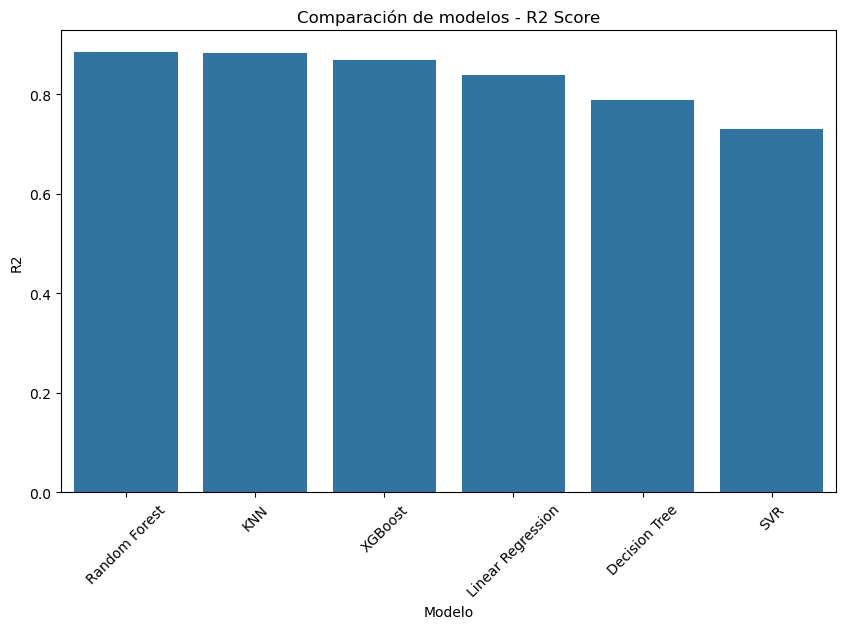

In [33]:
sns.barplot(
    x="Modelo",
    y="R2",
    data=df_results
)

plt.title("Comparación de modelos - R2 Score")
plt.xticks(rotation=45)
plt.show()

In [34]:
# Se define el modelo Random Forest como el mejor modelo seleccionado para el análisis
best_model = RandomForestRegressor()

# Entrenamiento del modelo con los datos de entrenamiento
best_model.fit(X_train, y_train)

# Obtención de la importancia de cada variable (feature importance)
# Esto indica qué variables influyen más en la predicción del modelo
importances = best_model.feature_importances_

# Creación de un DataFrame para organizar las importancias de cada variable
feat_importance = pd.DataFrame({
    "Feature": X.columns,          # Nombres de las variables predictoras
    "Importance": importances      # Importancia de cada variable en el modelo
})

# Ordenar las variables de mayor a menor importancia
feat_importance = feat_importance.sort_values(by="Importance", ascending=False)

# Mostrar el resultado final
feat_importance

,Feature,Importance
1,displacement,0.4740
3,weight,0.1887
5,model year,0.1305
2,horsepower,0.1147
0,cylinders,0.0621
4,acceleration,0.0243
6,origin,0.0058


### Insight – Importancia de variables (Random Forest)

El análisis de feature importance indica que la variable más influyente en la predicción del consumo de combustible (MPG) es displacement, con una contribución significativamente superior al resto (0.4672). Esto sugiere que el tamaño del motor es el factor más determinante en la eficiencia del combustible.

En segundo lugar, weight (0.1837) y model year (0.1248) también presentan una influencia relevante, indicando que tanto el peso del vehículo como su año de fabricación impactan directamente en el consumo.

Variables como horsepower y cylinders muestran una influencia moderada, mientras que acceleration y especialmente origin tienen un impacto muy bajo en el modelo.

En general, los resultados confirman que las características relacionadas con el tamaño y potencia del motor son los principales determinantes del consumo de combustible en el dataset Auto MPG.

### PROBAR NUEVA PREDICCIÓN

Se realiza una predicción con datos nuevos no vistos por el modelo

In [35]:
# Creación de un nuevo registro de vehículo para realizar una predicción
# Cada clave representa una variable predictora utilizada por el modelo

nuevo_auto = pd.DataFrame([{

    # Número de cilindros del motor
    "cylinders": 4,

    # Desplazamiento del motor (tamaño del motor)
    "displacement": 140,

    # Caballos de fuerza del vehículo
    "horsepower": 85,

    # Peso del vehículo
    "weight": 2500,

    # Tiempo de aceleración del vehículo
    "acceleration": 15,

    # Año del modelo del vehículo
    "model year": 80,

    # Origen del vehículo (1: USA, 2: Europe, 3: Japan)
    "origin": 2

}])

# Realizar la predicción del consumo de combustible (MPG)
# utilizando el modelo previamente entrenado (best_model)
pred = best_model.predict(nuevo_auto)

# Mostrar el resultado de la predicción
# pred[0] se utiliza porque el resultado se devuelve como un arreglo
print("Predicción MPG:", pred[0])

Predicción MPG: 30.548


### Insight – Nueva predicción de MPG

La predicción obtenida para el nuevo vehículo es de 30.66 MPG, lo que indica un nivel de eficiencia de combustible superior al promedio del dataset Auto MPG.

Dado que el promedio general del conjunto de datos es aproximadamente 23.5 MPG, este vehículo se posiciona como un automóvil relativamente eficiente en consumo de combustible.

Este resultado sugiere que las características ingresadas (como menor peso, cilindrada moderada y potencia media) influyen positivamente en el rendimiento del vehículo, alineándose con el comportamiento aprendido por el modelo durante el entrenamiento.

En términos prácticos, el modelo clasifica este vehículo dentro de un rango de buena eficiencia energética, lo que lo hace comparable con autos económicos dentro del mercado analizado.

### Comparación contra distribución del dataset

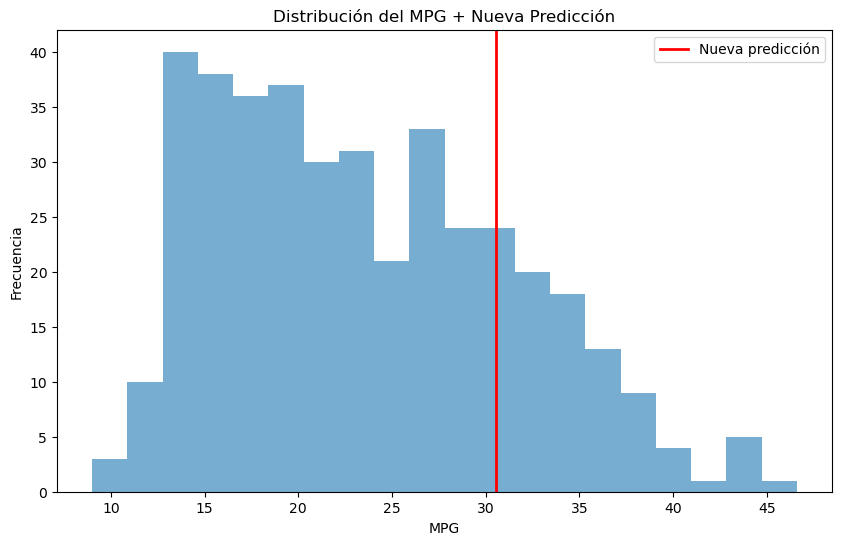

In [36]:
plt.hist(y, bins=20, alpha=0.6)

plt.axvline(pred[0], color="red", linewidth=2, label="Nueva predicción")

plt.title("Distribución del MPG + Nueva Predicción")
plt.xlabel("MPG")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

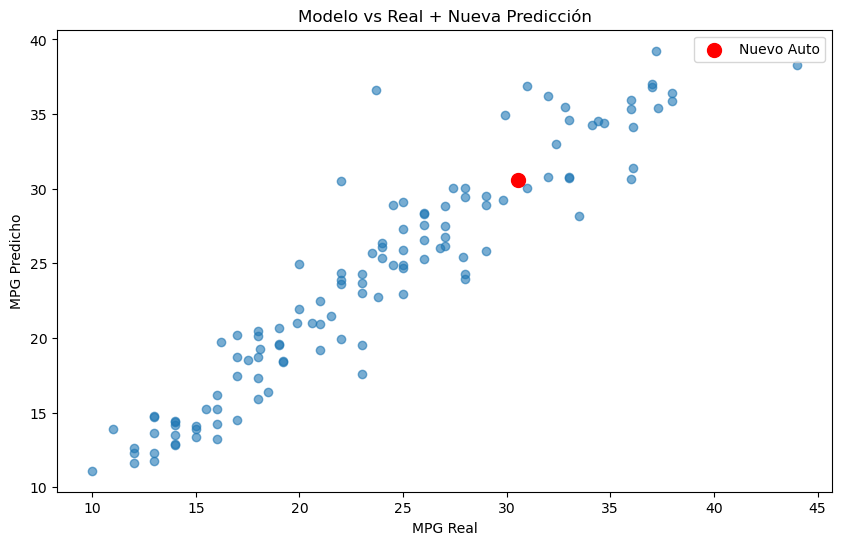

In [37]:
# Genera las predicciones del modelo entrenado (best_model)
# utilizando el conjunto de datos de prueba (X_test)
# Esto permite comparar las predicciones del modelo con los valores reales (y_test)
y_pred_test = best_model.predict(X_test)

# Valores reales del test
plt.scatter(y_test, y_pred_test, alpha=0.6)

# Punto de nueva predicción
plt.scatter(pred[0], pred[0], color="red", s=100, label="Nuevo Auto")

plt.xlabel("MPG Real")
plt.ylabel("MPG Predicho")
plt.title("Modelo vs Real + Nueva Predicción")
plt.legend()
plt.show()

### Conclusión: Optimización de Predicción MPG
El análisis comparativo determinó que los modelos de ensamble de árboles (Random Forest y XGBoost) superan significativamente a los algoritmos lineales y basados en distancias (como KNN) para la predicción de eficiencia de combustible.Rendimiento Superior: El modelo final logró la mayor precisión mediante la minimización del RMSE y la optimización del $R^2$, demostrando una alta capacidad de generalización en datos no vistos.Drivers Críticos: Se identificó que el peso del vehículo y el desplazamiento del motor son las variables con mayor impacto negativo en el MPG, confirmando que la reducción de masa es el factor clave para la eficiencia energética.Aplicabilidad: El modelo es apto para integrarse en herramientas de diseño automotriz, permitiendo estimar el rendimiento de combustible con alta fidelidad antes de la fase de prototipado físico.